# Automatic Game Balancing with Top Trumps (3 Objectives)

This notebook implements the three-objective optimization approach from:
> Volz, V., Rudolph, G., & Naujoks, B. (2016). "Demonstrating the Feasibility of Automatic Game Balancing" (GECCO '16)

**Objectives:**
1. **Fairness** - p4 (skilled player) win rate
2. **Excitement (trick changes)** - average number of lead changes during a game  
3. **Excitement (trick difference)** - how close the final score is (lower = tighter games)

In [1]:
import random
import numpy as np

from pymoo.core.problem import ElementwiseProblem
from pymoo.algorithms.moo.nsga3 import NSGA3
from pymoo.util.ref_dirs import get_reference_directions
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM
from pymoo.operators.sampling.lhs import LHS
from pymoo.optimize import minimize
from pymoo.termination import get_termination
from pymoo.visualization.pcp import PCP
import plotly.graph_objects as go
import matplotlib.pyplot as plt

## Top Trumps Implementation

In [ ]:
class TopTrumpsSimulation:
    """TopTrumpsSimulation implements the basic TopTrumps game engine and agent-based simulation."""

    def __init__(self, num_cards=52, num_categories=6):
        self.K = num_cards  # Number of cards
        self.L = num_categories  # Number of categories

        self.set_random_deck()

    def _normalize_deck(self, deck):
        """Normalizes the deck such that each property is in the range [0,1]. This is required for the p0 agent."""
        min_values = [0] * self.L
        max_values = [0] * self.L

        for cat in range(self.L):
            all_values = [card[cat] for card in deck]
            min_values[cat] = min(all_values)
            max_values[cat] = max(all_values)

        normalized_deck = []

        for card in deck:
            normalized_card = [0] * self.L
            for cat in range(self.L):
                normalized_card[cat] = (card[cat] - min_values[cat]) / (max_values[cat] - min_values[cat])
            normalized_deck.append(normalized_card)

        return normalized_deck

    def set_deck(self, deck_list):
        """Creates a deck from deck_list of length K*L."""

        assert len(deck_list) == self.K * self.L

        deck = np.array_split(deck_list, self.K)

        self.deck = deck
        self._normalized_deck = self._normalize_deck(deck)

    def set_random_deck(self, value_range = (1, 10)):
        """Generates a random deck with values in value_range."""
        deck_list = np.random.uniform(value_range[0], value_range[1], self.K * self.L)
        self.set_deck(deck_list)

    def get_p0_choice(self, card):
        """p0 assumes uniform distribution between max and min values per property and then picks the best value on current card."""
        return card.index(max(card))

    def get_p4_choice(self, card, remaining_cards):
        """p4 calculates exact win probability based on remaining cards."""
        best_prob = -1
        best_cat = 0

        for cat_idx in range(self.L):
            my_val = card[cat_idx]
            # Count how many cards in the potential card pool have a lower value
            wins = sum(1 for opp_card in remaining_cards if my_val > opp_card[cat_idx])
            prob = wins / len(remaining_cards)

            if prob > best_prob:
                best_prob = prob
                best_cat = cat_idx
        return best_cat

    def simulate_game(self):
        # Shuffle and distribute cards
        temp_deck = list(self._normalized_deck)
        random.shuffle(temp_deck)

        # p4 vs p0 setup
        p4_hand = temp_deck[:self.K//2]
        p0_hand = temp_deck[self.K//2:]

        # Track unplayed cards remaining in the 'unplayed' pool for p4's knowledge 
        all_unplayed = list(temp_deck) 

        p4_tricks = 0
        current_turn = random.choice(['p4', 'p0']) # Random starting player
        trick_changes = 0
        total_tricks = self.K // 2

        # Game ends after all cards played once
        for i in range(total_tricks):
            card_p4 = p4_hand[i]
            card_p0 = p0_hand[i]

            # Category Selection
            if current_turn == 'p4':
                category = self.get_p4_choice(card_p4, all_unplayed)
            else:
                category = self.get_p0_choice(card_p0)

            # Determine Round Winner
            val_p4 = card_p4[category]
            val_p0 = card_p0[category]

            # Remove current p0, p4 card from p4's tracking memory
            all_unplayed.remove(card_p0)
            all_unplayed.remove(card_p4)

            if val_p4 > val_p0:
                p4_tricks += 1
                if current_turn == 'p0':
                    current_turn = 'p4'
                    trick_changes += 1
            elif val_p0 > val_p4:
                if current_turn == 'p4':
                    current_turn = 'p0'
                    trick_changes += 1
            # In case of draw, current player keeps the lead

        # Calculate trick difference: |2*p4_tricks - total_tricks/2|
        # This measures how far the result is from a tie (K/4 tricks each)
        # Paper formula: |2*t4 - K/2| where K/2 is total tricks played
        trick_difference = abs(2 * p4_tricks - total_tricks / 2)

        return {
            "p4_tricks": p4_tricks,
            "trick_changes": trick_changes,
            "trick_difference": trick_difference,
            "p4_won": p4_tricks > (self.K / 4)  # p4 wins if they got more than half the tricks
        }

Test implementation on a random deck:

In [3]:
num_cards = 22
num_categories = 4
num_repetitions = 1000

sim = TopTrumpsSimulation(num_cards=num_cards, num_categories=num_categories)
sim.set_deck(np.random.uniform(0, 10, num_cards * num_categories))
results = [sim.simulate_game() for _ in range(num_repetitions)]

avg_p4_win_rate = sum(1 for r in results if r['p4_won']) / num_repetitions
avg_tricks = sum(r['p4_tricks'] for r in results) / num_repetitions
avg_trick_changes = sum(r['trick_changes'] for r in results) / num_repetitions
avg_trick_difference = sum(r['trick_difference'] for r in results) / num_repetitions

print(f"Results over {num_repetitions} runs:")
print(f"p4 Win Rate: {avg_p4_win_rate:.2%}")
print(f"Average p4 Tricks: {avg_tricks:.2f}")
print(f"Average Trick Changes: {avg_trick_changes:.2f}")
print(f"Average Trick Difference: {avg_trick_difference:.2f}")

Results over 1000 runs:
p4 Win Rate: 55.40%
Average p4 Tricks: 5.98
Average Trick Changes: 1.71
Average Trick Difference: 7.70


## Pymoo connection

TopTrumpsBalancing provides a pymoo-compatible interface for TopTrumpsSimulation. Note that the objectives are already negated to result in a minimization problem!

In [4]:
class TopTrumpsBalancing(ElementwiseProblem):
    """
    TopTrumpsBalancing connects TopTrumpsSimulation with the pymoo interface.
    
    Three objectives (all minimization):
    - f1: -p4_win_rate (Fairness - we want high win rate for skilled player)
    - f2: -trick_changes (Excitement - we want many lead changes)
    - f3: +trick_difference (Excitement - we want close games, low difference)
    """

    def __init__(self, sim_instance, n_simulations=100):
        self.sim = sim_instance
        self.n_simulations = n_simulations
        
        # KL variables: Number of cards (K) * Categories (L) 
        n_var = self.sim.K * self.sim.L
        
        super().__init__(n_var=n_var,
                         n_obj=3,  # 3 objectives now
                         n_constr=0,
                         xl=1.0,   # Lower bound for values
                         xu=10.0)  # Upper bound for values

    def _evaluate(self, x, out, *args, **kwargs):
        # Update simulation with the current candidate deck
        self.sim.set_deck(x)
        
        win_rates = []
        trick_changes_list = []
        trick_diff_list = []
        
        # Perform multiple simulations to get an average
        for _ in range(self.n_simulations):
            res = self.sim.simulate_game()
            win_rates.append(1 if res['p4_won'] else 0)
            trick_changes_list.append(res['trick_changes'])
            trick_diff_list.append(res['trick_difference'])
        
        # Objectives (all Minimization):
        # f1: -Average Win Rate of p4 (Fairness) - negate to maximize
        # f2: -Average Trick Changes (Excitement) - negate to maximize
        # f3: +Average Trick Difference (Excitement) - already minimize (want low diff)
        out["F"] = [
            -np.mean(win_rates), 
            -np.mean(trick_changes_list),
            np.mean(trick_diff_list)
        ]

Set up simulation and problem instance:

In [5]:
my_sim = TopTrumpsSimulation(num_cards=22, num_categories=4)
problem = TopTrumpsBalancing(my_sim, n_simulations=1000)

## NSGA-III Optimization

For 3+ objectives, NSGA-III is preferred over NSGA-II as it uses reference-point based selection which better maintains diversity across the Pareto front.

In [6]:
# Parameters
K = 22  # Number of cards
L = 4   # Number of categories
N_SIM = 1000  # Simulations per evaluation
N_GEN = 100   # Number of generations
SEED = 42

# Create simulation and problem
sim = TopTrumpsSimulation(num_cards=K, num_categories=L)
problem = TopTrumpsBalancing(sim, n_simulations=N_SIM)

# Reference directions for 3 objectives
# n_partitions controls the number of reference points on the unit simplex
ref_dirs = get_reference_directions("das-dennis", 3, n_partitions=12)

# NSGA-III algorithm setup
algorithm = NSGA3(
    pop_size=100,
    ref_dirs=ref_dirs,
    sampling=LHS(),
    crossover=SBX(eta=10, prob=0.9),
    mutation=PM(eta=15, prob=1.0 / (K * L)),
)

# Termination criterion
termination = get_termination("n_gen", N_GEN)

print(f"Problem: {K} cards × {L} categories = {K*L} decision variables")
print(f"Objectives: 3 (fairness, trick changes, trick difference)")

Problem: 22 cards × 4 categories = 88 decision variables
Objectives: 3 (fairness, trick changes, trick difference)


In [7]:
# Run optimization
result = minimize(
    problem,
    algorithm,
    termination,
    seed=SEED,
    verbose=True
)

n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |      100 |      8 |             - |             -
     2 |      200 |     13 |  0.0202020202 |         ideal
     3 |      300 |      7 |  0.2676579926 |         ideal
     4 |      400 |     11 |  0.1047619048 |         ideal
     5 |      500 |     13 |  0.0940170940 |         nadir
     6 |      600 |     13 |  0.1456310680 |         ideal
     7 |      700 |     11 |  0.2043795620 |         ideal
     8 |      800 |     13 |  0.0291970803 |         ideal
     9 |      900 |     10 |  0.0944123314 |         ideal
    10 |     1000 |      8 |  0.0593080725 |         ideal
    11 |     1100 |     13 |  0.0045161290 |         ideal
    12 |     1200 |      9 |  0.1111111111 |         ideal
    13 |     1300 |     10 |  0.0816326531 |         ideal
    14 |     1400 |     11 |  0.0878210439 |         ideal
    15 |     1500 |     11 |  0.0415504672 |             f
    16 |     1600 |     13 |  0.0503703704 |         ide

## Visualization of Pareto Front

In [14]:
# Convert objectives back to intuitive values (undo negation for display)
F = result.F.copy()
fairness = -F[:, 0]      # p4 win rate (higher = better)
trick_changes = -F[:, 1]  # lead changes (higher = better)
trick_diff = F[:, 2]      # trick difference (lower = better)

# Find extreme and balanced solutions for highlighting
best_fairness_idx = np.argmax(fairness)
best_trick_changes_idx = np.argmax(trick_changes)
best_trick_diff_idx = np.argmin(trick_diff)

# Balanced solution (closest to ideal after normalization)
def normalize_col(col):
    return (col - col.min()) / (col.max() - col.min() + 1e-10)

norm_arr = np.column_stack([
    normalize_col(fairness),
    normalize_col(trick_changes),
    1 - normalize_col(trick_diff)
])
balanced_idx = np.argmin(np.sqrt(np.sum((norm_arr - 1) ** 2, axis=1)))

### Interactive 3D Pareto Front (Plotly)

Drag to rotate, scroll to zoom. Hover over points for details.

In [16]:
# Create labels for each point
labels = []
for i in range(len(fairness)):
    label = f"Solution {i+1}<br>"
    label += f"Fairness: {fairness[i]:.3f}<br>"
    label += f"Trick Changes: {trick_changes[i]:.2f}<br>"
    label += f"Trick Diff: {trick_diff[i]:.2f}"
    
    # Add special tags
    if i == best_fairness_idx:
        label += "<br><b>★ Best Fairness</b>"
    if i == best_trick_changes_idx:
        label += "<br><b>★ Most Exciting</b>"
    if i == best_trick_diff_idx:
        label += "<br><b>★ Closest Games</b>"
    if i == balanced_idx:
        label += "<br><b>★ Most Balanced</b>"
    labels.append(label)

# Create main scatter trace
fig = go.Figure()

# All solutions
fig.add_trace(go.Scatter3d(
    x=fairness,
    y=trick_changes,
    z=trick_diff,
    mode='markers',
    marker=dict(
        size=8,
        color=trick_diff,
        colorscale='RdYlGn_r',
        colorbar=dict(title="Trick Diff<br>(lower=better)", x=1.02),
        opacity=0.8,
        line=dict(width=1, color='white')
    ),
    text=labels,
    hoverinfo='text',
    name='Pareto Solutions'
))

# Highlight special solutions
special_points = [
    (best_fairness_idx, 'Best Fairness', 'blue', 'diamond'),
    (best_trick_changes_idx, 'Most Exciting', 'lime', 'diamond'),
    (best_trick_diff_idx, 'Closest Games', 'red', 'diamond'),
    (balanced_idx, 'Balanced', 'gold', 'diamond'),
]

for idx, name, color, symbol in special_points:
    fig.add_trace(go.Scatter3d(
        x=[fairness[idx]],
        y=[trick_changes[idx]],
        z=[trick_diff[idx]],
        mode='markers',
        marker=dict(size=12, color=color, symbol=symbol, 
                    line=dict(width=2, color='black')),
        name=name,
        hoverinfo='text',
        text=[labels[idx]]
    ))

# Update layout
fig.update_layout(
    title=dict(
        text='<b>Interactive 3D Pareto Front</b><br><sub>Drag to rotate, scroll to zoom</sub>',
        x=0.5
    ),
    scene=dict(
        xaxis_title='Fairness (p4 Win Rate)',
        yaxis_title='Trick Changes',
        zaxis_title='Trick Difference',
        xaxis=dict(backgroundcolor='rgba(230,230,230,0.5)'),
        yaxis=dict(backgroundcolor='rgba(230,230,230,0.5)'),
        zaxis=dict(backgroundcolor='rgba(230,230,230,0.5)'),
    ),
    width=900,
    height=700,
    legend=dict(x=0.02, y=0.98, bgcolor='rgba(255,255,255,0.8)')
)

fig.show()

## 2D Pairwise Projections

Pairwise projections help understand the trade-offs between each pair of objectives.

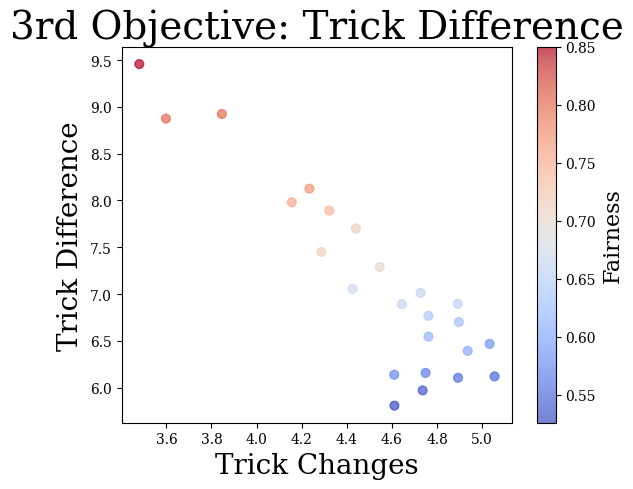

In [25]:
fig, ax = plt.subplots(figsize=(6, 5))

scatter = ax.scatter(trick_changes, trick_diff, c=fairness, cmap='coolwarm', s=40, alpha=0.7)

ax.set_xlabel('Trick Changes', fontsize=20)
ax.set_ylabel('Trick Difference', fontsize=20)
ax.set_title('3rd Objective: Trick Difference', fontsize=28)

# Add the colorbar
cbar = plt.colorbar(scatter, ax=ax, label='Fairness')
cbar.ax.yaxis.label.set_size(16)

plt.tight_layout()
# Saving with a relevant filename for the single plot
plt.savefig("plots/trick_changes_vs_trick_diff.svg")
plt.show()

## Objective Distribution on Pareto Front

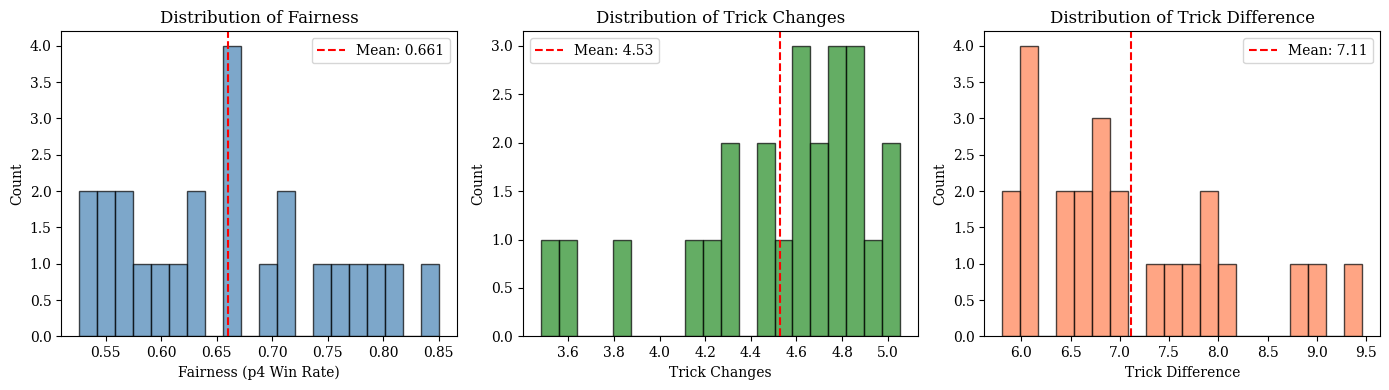

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(fairness, bins=20, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Fairness (p4 Win Rate)')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Fairness')
axes[0].axvline(fairness.mean(), color='red', linestyle='--', label=f'Mean: {fairness.mean():.3f}')
axes[0].legend()

axes[1].hist(trick_changes, bins=20, color='forestgreen', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Trick Changes')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of Trick Changes')
axes[1].axvline(trick_changes.mean(), color='red', linestyle='--', label=f'Mean: {trick_changes.mean():.2f}')
axes[1].legend()

axes[2].hist(trick_diff, bins=20, color='coral', edgecolor='black', alpha=0.7)
axes[2].set_xlabel('Trick Difference')
axes[2].set_ylabel('Count')
axes[2].set_title('Distribution of Trick Difference')
axes[2].axvline(trick_diff.mean(), color='red', linestyle='--', label=f'Mean: {trick_diff.mean():.2f}')
axes[2].legend()

plt.tight_layout()
plt.show()